## Step01

In [ ]:
import pandas as pd
from pathlib import Path

# Load
DATA_PATH = Path("data/project_dataset.csv")
df = pd.read_csv(DATA_PATH, sep=";")

print("csv file is loaded successfully")
print("raw shape:", df.shape)

## data inspection checking for missing data
#    Replace common textual missings by real NaN
text_missing_patterns = r"^\s*(nan|none|null)\s*$"
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(text_missing_patterns, pd.NA, regex=True)

# date + drop invalid dates
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).copy()

## removing duplicates by route+date
route_subset = ["Date", "Service", "Gare de départ", "Gare d'arrivée"]

before = df.shape[0]
df = df.drop_duplicates(subset=route_subset).copy()
after = df.shape[0]

print(f"Removed {before - after} duplicate routes")
print("OK duplicates removed")

# --- CATEGORICAL TEXT ---
categorical_cols = [
    "Service",
    "Gare de départ",
    "Gare d'arrivée",
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée",
]

text_missing_patterns = r"^\s*(nan|none|null|na)\s*$"

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        # replace textual "nan", "none", "null" with real NaN
        df[col] = df[col].replace(text_missing_patterns, pd.NA, regex=True)
        df[col] = df[col].astype("category")

print("OK text columns handled")

# --- INTEGER COUNTS ---
count_cols = [
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Nombre de trains en retard à l'arrivée",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
]

for col in count_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[df[col] < 0, col] = 0
print((pd.to_numeric(df["Nombre trains en retard > 30min"], errors="coerce") < 0).sum())

delay_cols = [
    "Durée moyenne du trajet",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
]

for col in delay_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[df[col] < 0, col] = 0

int_cols = [
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Nombre de trains en retard à l'arrivée",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
]

for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")


# --- FLOAT / CONTINUOUS VALUES ---
float_cols = [
    "Durée moyenne du trajet",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",
]

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Feature engineering
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Final Date format for export
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

# Final safety checks
print("clean shape:", df.shape)
print("Date missing values:", df["Date"].isna().sum())

# check textual "nan" isn't present anymore anywhere
bad_text = {}
for col in df.columns:
    if df[col].dtype == "object":
        bad_text[col] = (
            df[col]
            .astype(str)
            .str.contains(text_missing_patterns, regex=True, na=False)
            .sum()
        )
bad_text = {k: v for k, v in bad_text.items() if v > 0}
print("textual nan counts (must be empty):", bad_text)

df = df.rename(columns={"Gare de départ": "Departure station"})

## Export
CLEAN_PATH = Path("cleaned_dataset.csv")
df.to_csv(CLEAN_PATH, index=False)
print("cleaned dataset saved to:", CLEAN_PATH)

csv file is loaded successfully
raw shape: (12070, 26)
Removed 186 duplicate routes
OK duplicates removed
OK text columns handled
0
clean shape: (11572, 28)
Date missing values: 0
textual nan counts (must be empty): {}


C:\Users\samir\AppData\Local\Temp\ipykernel_4808\1433785184.py:138: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(text_missing_patterns, regex=True, na=False)


cleaned dataset saved to: cleaned_dataset.csv


In [3]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("cleaned_dataset.csv")

print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)

for col in df.columns:
    print(f"\nColumn   : {col}")
    print(f"Type     : {df[col].dtype}")
    print(f"Missing  : {df[col].isnull().sum()} ({df[col].isnull().mean() * 100:.1f}%)")
    print(f"Unique   : {df[col].nunique()}")
    if df[col].dtype in ["float64", "Int64", "int64"]:
        print(f"Min      : {df[col].min()}")
        print(f"Max      : {df[col].max()}")
        print(f"Mean     : {df[col].mean():.2f}")
    elif df[col].dtype.name == "category" or df[col].dtype == "object":
        print(f"Sample   : {df[col].dropna().unique()[:5]}")

Shape: 11572 rows × 28 columns

Column   : Date
Type     : object
Missing  : 0 (0.0%)
Unique   : 96
Sample   : ['2018-01-01' '2018-02-01' '2018-03-01' '2018-04-01' '2018-05-01']

Column   : Service
Type     : object
Missing  : 228 (2.0%)
Unique   : 2
Sample   : ['National' 'International']

Column   : Departure station
Type     : object
Missing  : 58 (0.5%)
Unique   : 107
Sample   : ['BORDEAUX ST JEAN' 'LE MANS' 'PARIS MONTPARNASSE' 'POITIERS' 'ST MALO']

Column   : Gare d'arrivée
Type     : object
Missing  : 58 (0.5%)
Unique   : 98
Sample   : ['PARIS MONTPARNASSE' 'LA ROCHELLE VILLE' 'NANTES' 'PARIS EST'
 'PARIS NORD']

Column   : Durée moyenne du trajet
Type     : float64
Missing  : 356 (3.1%)
Unique   : 493
Min      : 0.0
Max      : 786.0
Mean     : 170.98

Column   : Nombre de circulations prévues
Type     : float64
Missing  : 259 (2.2%)
Unique   : 875
Min      : 0.0
Max      : 1100.0
Mean     : 270.68

Column   : Nombre de trains annulés
Type     : float64
Missing  : 259 (2.2%)
Un

# Exploratory Data Analysis (EDA)

In [59]:
from pathlib import Path
import pandas as pd

CLEAN_PATH = Path("cleaned_dataset.csv")
df = pd.read_csv(CLEAN_PATH)

df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",Year,Month
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,NaN,289.0,11.247809,...,44.0,8.0,36.134454,31.092437,10.924370,15.966387,NaN,0.840336,2018,1
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,NaN,213.0,8.479969,...,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,NaN,21.0,6.239683,...,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211,...,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,NaN,224.0,6.784673,...,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018,1


In [60]:
round(df["Retard moyen des trains en retard au départ"].mean(), 2)

np.float64(12.32)

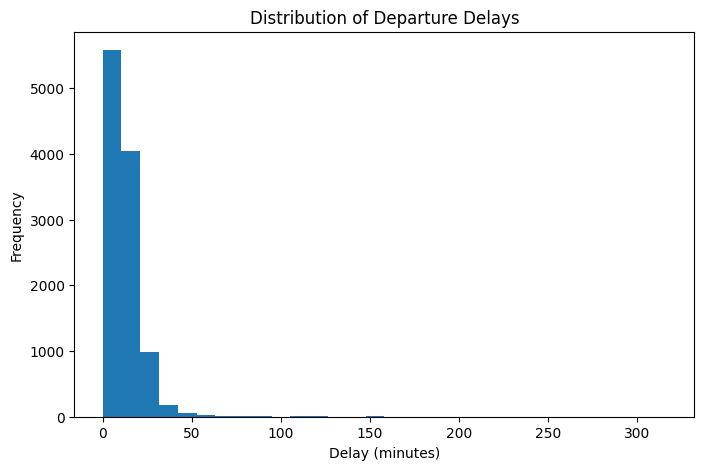

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Retard moyen des trains en retard au départ"], bins=30)
plt.title("Distribution of Departure Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

In [62]:
avg_delay_by_year = (
    df.groupby("Year")["Retard moyen des trains en retard au départ"]
    .mean()
    .sort_index()
)
avg_delay_by_year

Year
2018    12.273274
2019    12.645850
2020     4.632618
2021    11.801148
2022    13.229736
2023    14.554805
2024    14.039406
2025    15.343313
Name: Retard moyen des trains en retard au départ, dtype: float64

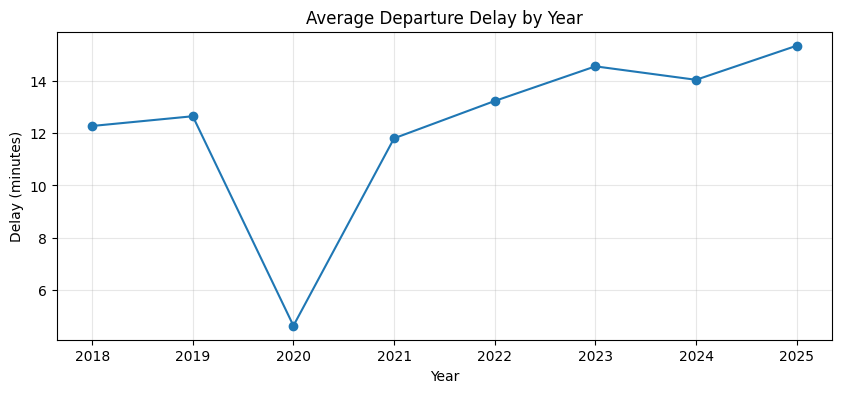

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(avg_delay_by_year.index, avg_delay_by_year.values, marker="o")
plt.title("Average Departure Delay by Year")
plt.xlabel("Year")
plt.ylabel("Delay (minutes)")
plt.grid(True, alpha=0.3)
plt.show()

### Insight: Evolution of Departure Delays Over Time

The average departure delay significantly dropped in 2020 (4.59 minutes), likely due to reduced train traffic during the COVID-19 period
However, from 2021 onwards, delays increased steadily, reaching more than 15 minutes in 2025.This suggests a worsening delay trend in recent years

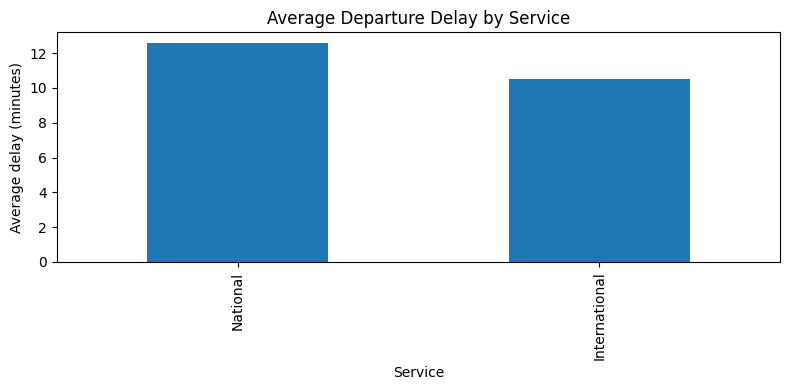

Service
National         12.570563
International    10.543705
Name: Retard moyen des trains en retard au départ, dtype: float64

In [64]:
import matplotlib.pyplot as plt

# We calculate the average departure delay but separated by "Service"
avg_delay_by_service = (
    df.groupby("Service")["Retard moyen des trains en retard au départ"]
    .mean()
    .sort_values(ascending=False)
)

# The result is displayed in a bar chart
plt.figure(figsize=(8, 4))
avg_delay_by_service.plot(kind="bar")
plt.title("Average Departure Delay by Service")
plt.xlabel("Service")
plt.ylabel("Average delay (minutes)")
plt.tight_layout()
plt.show()

# (optional) display the values
avg_delay_by_service

## Insight: Delay Differences by Service Type

The average departure delay is higher for National services (≈12.57 minutes) compared to International services (≈10.53 minutes)

This suggests that national routes experience more significant delays on average.  
Possible explanations may include higher traffic density, more intermediate stops, or infrastructure constraints affecting domestic routes

This analysis introduces a second comparison dimension (service type), complementing the temporal analysis by year